<a href="https://colab.research.google.com/github/Sachinsachin21/Deep_learning/blob/main/spell_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("final.csv")

In [ ]:
data = data.dropna(axis=1, how='all')
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]
data.to_csv("final.csv", index=False)

In [ ]:
data.isnull().values.any()

True

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.duplicated().sum()

1133

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.shape

(20427, 2)

In [ ]:
data.head()

,Misspelling,Corrected
0,strang,range
1,brake,break
2,brack,break
3,weanter,winter
4,gost,ghost


In [ ]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(data['Misspelling'].tolist() + data['Corrected'].tolist())
x = tokenizer.texts_to_sequences(data['Misspelling'])
y = tokenizer.texts_to_sequences(data['Corrected'])

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
max_length = 20

In [ ]:
vocab_size

32

In [ ]:
x = pad_sequences(x, maxlen=max_length, padding='post')
y = pad_sequences(y, maxlen=max_length, padding='post')


In [ ]:
def create_padding_mask(seq):
    mask = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

In [ ]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model) // 2)) / d_model)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)


In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)

        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        attention = tf.reshape(attention, (batch_size, -1, self.d_model))
        output = self.dense(attention)
        return output

    def scaled_dot_product_attention(self, q, k, v, mask):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

In [ ]:
class PositionwiseFeedforward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff):
        super(PositionwiseFeedforward, self).__init__()
        self.d_model = d_model
        self.dff = dff
        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return x

In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedforward(d_model, dff)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, training, mask):
        attn_output = self.att(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

In [ ]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)
        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, training, mask):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)
        return x

In [ ]:
class Transformer(Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, pe_input, target_vocab_size, rate=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, pe_input, rate)
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs, training=False, mask=None):
      if mask is None:
          mask = create_padding_mask(inputs)
      enc_output = self.encoder(inputs, training=training, mask=mask)
      return self.final_layer(enc_output)

In [ ]:
num_layers = 4
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = vocab_size
target_vocab_size = vocab_size
pe_input = max_length
dropout_rate = 0.2

In [ ]:
transformer = Transformer(num_layers, d_model, num_heads, dff, input_vocab_size, pe_input, target_vocab_size, rate=dropout_rate)

In [ ]:
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder (Encoder)                    │ ?                           │         797,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 20, 32)              │           4,128 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,403,938 (9.17 MB)

 Trainable params: 801,312 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,602,626 (6.11 MB)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [ ]:
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
transformer.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = transformer.fit(x_train,y_train,epochs=30,batch_size=32,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.5202 - loss: 1.9401 - val_accuracy: 0.6156 - val_loss: 1.2979
Epoch 2/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.6034 - loss: 1.3607 - val_accuracy: 0.6187 - val_loss: 1.2787
Epoch 3/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6098 - loss: 1.3276 - val_accuracy: 0.6331 - val_loss: 1.2393
Epoch 4/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6188 - loss: 1.2852 - val_accuracy: 0.6473 - val_loss: 1.1770
Epoch 5/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6319 - loss: 1.2307 - val_accuracy: 0.6653 - val_loss: 1.0883
Epoch 6/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6503 - loss: 1.1514 - val_accuracy: 0.7055 - val_loss: 0.9564
Epoch 7/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6795 - loss: 1.0456 - val_accuracy: 0.7478 - val_loss: 0.8291
Epoch 8/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7086 - loss: 0.9540 - val_accuracy:

In [ ]:
test_loss, test_accuracy = transformer.evaluate(x_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8501 - loss: 0.4903
Test Loss: 0.4899804890155792
Test Accuracy: 0.8503589630126953


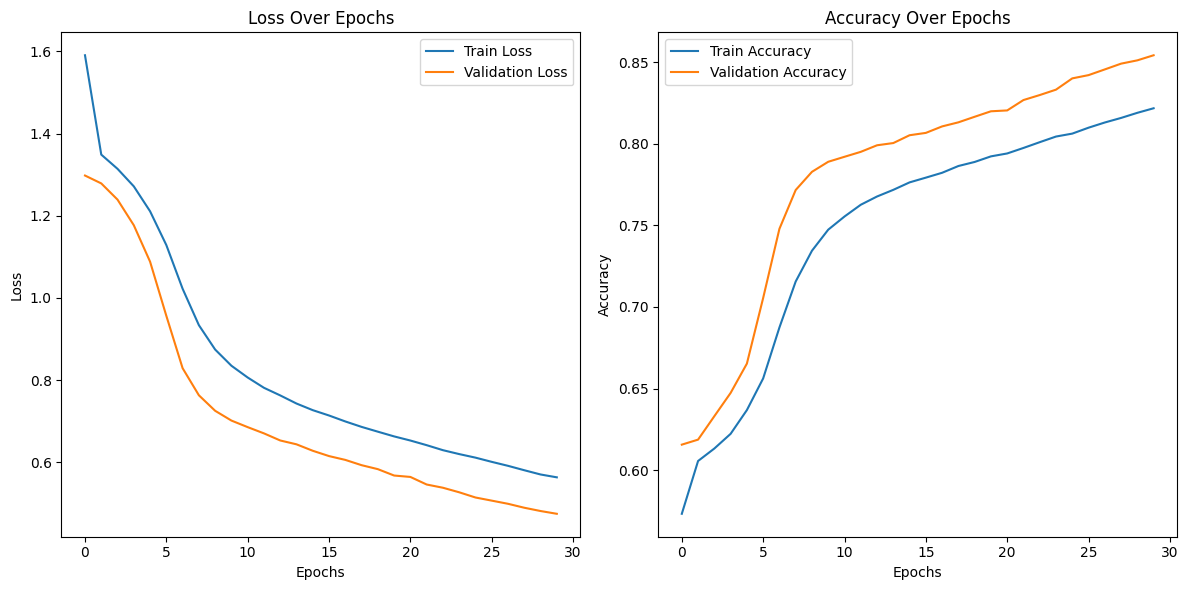

In [ ]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')


plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.tight_layout()
plt.show()

In [ ]:
def predict_spelling_correction(misspelled_word, model, tokenizer, max_length):
    input_sequence = tokenizer.texts_to_sequences([misspelled_word])
    input_sequence = pad_sequences(input_sequence, maxlen=max_length, padding='post')
    predictions = model.predict(input_sequence)
    predicted_indices = tf.argmax(predictions, axis=-1).numpy()[0]
    corrected_word = ''.join([tokenizer.index_word[idx] for idx in predicted_indices if idx > 0])

    return corrected_word.strip()
user_input = input("Enter a misspelled word: ").strip()

corrected_spelling = predict_spelling_correction(user_input, transformer, tokenizer, max_length)

print(f"Corrected spelling: {corrected_spelling}")

Enter a misspelled word: speciman
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Corrected spelling: specimen


In [ ]:
transformer.save('spelling_correction_model.h5')

In [ ]:
from google.colab import files
files.download('spelling_correction_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def gradio_predict(misspelled_word):
    return predict_spelling_correction(misspelled_word, transformer, tokenizer, max_length)

In [ ]:
interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(label="Enter a Misspelled Word"),
    outputs=gr.Textbox(label="Corrected Spelling"),
    title="Spelling Correction Model",
    description="Enter a misspelled word, and the model will correct it for you."
)

interface.launch(debug=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6c80011fd6a986e00e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6c80011fd6a986e00e.gradio.live
